## Support Vector Machine (SVM) — Hinge Loss Optimization

---

### 1. Problem Setup

Assume we have a dataset

$$
\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_N, y_N)\}
$$

where

$$
\mathbf{x}_i \in \mathbb{R}^D
$$

$$
y_i \in \{-1, +1\}
$$

The goal is to find a decision boundary that separates the two classes with maximum margin.

---

### 2. Linear Model

The model predicts using a linear function:

$$
f(\mathbf{x}_i) = \mathbf{w}^T \mathbf{x}_i
$$

If bias term is included:

$$
\tilde{\mathbf{x}}_i = [1, \mathbf{x}_i]
$$

Then the prediction becomes:

$$
f(\mathbf{x}_i) = \mathbf{w}^T \tilde{\mathbf{x}}_i
$$

---

### 3. Decision Rule

The predicted class is:

$$
\hat{y}_i = \text{sign}(f(\mathbf{x}_i))
$$

---

### 4. Objective Function (Hinge Loss + Regularization)

The SVM objective is:

$$
L = \frac{1}{2} \|\mathbf{w}\|_2^2 + C \sum_{i=1}^{N} \max(0, 1 - y_i (\mathbf{w}^T \mathbf{x}_i))
$$

Or using mean hinge loss:

$$
L = \frac{1}{2} \|\mathbf{w}\|_2^2 + C \cdot \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i (\mathbf{w}^T \mathbf{x}_i))
$$

---

### 5. Margin Condition

Define margin:

$$
\text{margin}_i = y_i (\mathbf{w}^T \mathbf{x}_i)
$$

- If:

$$
\text{margin}_i \geq 1
$$

→ Correctly classified with sufficient margin

- If:

$$
\text{margin}_i < 1
$$

→ Inside margin or misclassified

---

### 6. Gradient Update Rule

For each sample:

#### Case 1: Correct classification with margin

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \mathbf{w}
$$

(Bias term is not regularized)

---

#### Case 2: Misclassified or inside margin

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta (\mathbf{w} - C y_i \mathbf{x}_i)
$$

---

### 7. Weight Initialization

Initialize weights to zeros:

$$
\mathbf{w} = \mathbf{0}
$$

---

### 8. Iterative Optimization

For each epoch:

1. Loop over all samples  
2. Compute margin:

$$
\text{margin}_i = y_i (\mathbf{w}^T \mathbf{x}_i)
$$

3. Update weights based on condition:

- If margin ≥ 1 → regularization update  
- Else → hinge loss update  

4. Compute full loss:

$$
L = \frac{1}{2} \|\mathbf{w}\|_2^2 + C \cdot \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i (\mathbf{w}^T \mathbf{x}_i))
$$

---

### 9. Convergence Criterion

Stop early if improvement is smaller than tolerance:

$$
|L_{\text{current}} - L_{\text{previous}}| < \text{tol}
$$

---

### 10. Prediction

After training, predictions for new data $\mathbf{X}_{\text{test}}$ are:

$$
\mathbf{y}_{\text{pred}} = \mathbf{X}_{\text{test}} \mathbf{w}
$$

Final class prediction:

$$
\hat{y} = 
\begin{cases}
+1 & \text{if } \mathbf{X}\mathbf{w} \geq 0 \\
-1 & \text{otherwise}
\end{cases}
$$

---

### 11. Algorithm Summary

1. Initialize weights: $\mathbf{w} = 0$  

2. Repeat for each epoch:  
   - Loop through each sample  
   - Compute margin  
   - Update weights based on margin condition  
   - Compute full loss  

3. Stop if convergence criterion met  

4. Predict using:

$$
\hat{y} = \text{sign}(\mathbf{X}\mathbf{w})
$$

---

### 12. Geometric Interpretation

- The decision boundary is:

$$
\mathbf{w}^T \mathbf{x} = 0
$$

- Margin boundaries:

$$
\mathbf{w}^T \mathbf{x} = \pm 1
$$

- SVM maximizes the distance between these margins, leading to better generalization.

In [1]:
class SVM:
    """
    Support Vector Machine (SVM) classifier using hinge loss optimization.

    Parameters
    ----------
    learning_rate : float, default=0.01
        Step size for weight updates during training.
    C : float, default=1
        Regularization parameter controlling trade-off between margin maximization 
        and classification error.
    add_bias : bool, default=True
        Whether to include a bias (intercept) term.
    epochs : int, default=10
        Number of passes over the training dataset.
    tol : float, default=0.01
        Tolerance for early stopping based on loss improvement.
    """

    
    def __init__(self, learning_rate=0.01 , C=1 , add_bias = True , epochs=10 , tol=0.01):
        self.learning_rate = learning_rate
        self.C = C
        self.add_bias = add_bias
        self.epochs = epochs
        self.tol =tol

        # Weights will be initialized during training
        self.weights = None



    def fit(self,X,y):
        """
        Train the SVM model using stochastic gradient descent.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training feature matrix.
        y : ndarray of shape (n_samples,)
            Target labels, expected to be in {-1, +1}.

        Notes
        -----
        - Uses hinge loss with L2 regularization.
        - Updates weights sample-by-sample (SGD style).
        - Stops early if loss improvement is smaller than tolerance.
        """

        # Convert inputs to numpy arrays
        X = np.asarray(X)
        y = np.asarray(y)

        # Ensure y is a 1D array
        y = y.reshape(-1)
        
        # Ensure X is 2D
        if X.ndim==1 :
            X = X.reshape(-1,1)

            
        
        N , D = X.shape
        
        # Add bias term if required
        if self.add_bias :
            X = np.column_stack((np.ones(N),X))
            D += 1
        # Initialize weights to zero
        self.weights = np.zeros(D)

        
        # Precompute y_i * x_i for efficiency
        product_of_xy = y[:,None] * X
        loss_prev = np.inf
        
        for epoch in range(self.epochs):
            
            # Loop through each sample (SGD)
            for sample in range(N):
                
                # Compute margin: y_i * (w^T x_i)
                margin_i = self.weights @ product_of_xy[sample, :]

                if margin_i >= 1:
                    # Only regularization term (no hinge loss contribution)
                    # Do not regularize bias term
                    self.weights[1:] -= self.learning_rate * self.weights[1:]

                else :
                    # Misclassified or within margin → apply full update
                    self.weights -= self.learning_rate * (self.weights - self.C * product_of_xy[sample, :])

            # Compute full loss (hinge + regularization)
            loss_curr = 0.5 * np.linalg.norm(self.weights,ord=2)**2 + self.C * np.mean(np.maximum(0,1- (product_of_xy @ self.weights)))
    
            # early stopping condition
            if abs(loss_prev - loss_curr) < self.tol:
                print(f"Stopping early at epoch {epoch}: improvement < {self.tol}")
                print(f'The model weights are: {self.weights}')
                break
    
            loss_prev = loss_curr
            
            # Print loss for monitoring
            print(f'Loss at epoch: {epoch} is {loss_curr}')


    def predict(self,X):
        """
        Predict class labels for input data.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Input feature matrix.

        Returns
        -------
        y_pred : ndarray of shape (n_samples,)
            Predicted class labels in {-1, +1}.
        """
        # Ensure model is trained
        if self.weights is None:
            raise ValueError("Model is not fitted yet")

        # Convert input to numpy array
        X = np.asarray(X)

        # Ensure X is 2D
        if X.ndim==1 :
            X = X.reshape(-1,1)

        N = len(X)

        # Add bias term if model was trained with bias
        if self.add_bias :
            X = np.column_stack((np.ones(N),X))
            
        # Compute linear scores
        y_pred = X @ self.weights
        
        # Convert scores to class labels {-1, +1}
        return np.where(y_pred >= 0, 1, -1)      

### 1. Objective

The goal is to:

- Train a **linear SVM classifier** on a synthetic dataset  
- Visualize the **decision boundary**  
- Observe the **margin separation** between classes  

---



### 2. Dataset Generation

Create a **linearly separable dataset** with two classes:

- Class $+1$: centered at $(2, 2)$  
- Class $-1$: centered at $(-2, -2)$  

Each class contains $N = 50$ samples in $\mathbb{R}^2$.

Mathematically:

$$
\mathbf{x}_i^{(+)} \sim \mathcal{N}((2,2), I)
$$

$$
\mathbf{x}_i^{(-)} \sim \mathcal{N}((-2,-2), I)
$$

The dataset is:

$$
\mathbf{X} \in \mathbb{R}^{100 \times 2}, \quad y \in \{-1, +1\}
$$

---


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


N = 50  # points per class
D = 2   # features

# Class +1: centered at (2,2)
X_pos = np.random.randn(N, D) + 2
y_pos = np.ones(N)

# Class -1: centered at (-2,-2)
X_neg = np.random.randn(N, D) - 2
y_neg = -np.ones(N)

# Combine
X_train = np.vstack([X_pos, X_neg])
y_train = np.hstack([y_pos, y_neg])


--- 

### 3. Model Configuration and Training

We train a linear SVM with the following parameters:

- Learning rate: $\eta = 0.001$  
- Regularization parameter: $C = 25$  
- Number of epochs: $100$  
- Tolerance: $0.01$  


The SVM learns a weight vector:

$$
\mathbf{w} = [b, w_1, w_2]
$$

where:
- $b$ is the bias term  
- $w_1, w_2$ are feature weights  

The decision function is:

$$
f(\mathbf{x}) = b + w_1 x_1 + w_2 x_2
$$

---



In [3]:
model = SVM(learning_rate=0.001, C=25  , epochs=1000 , tol=0.01)
model.fit(X_train , y_train)

Loss at epoch: 0 is 0.7380718712607813
Loss at epoch: 1 is 0.49926901091268694
Loss at epoch: 2 is 0.4456390467613589
Loss at epoch: 3 is 0.46914466839027424
Loss at epoch: 4 is 0.5251593909489196
Loss at epoch: 5 is 0.4783858254516804
Stopping early at epoch 6: improvement < 0.01
The model weights are: [-0.10235031  0.72567285  0.53754684]


---

### 4. Decision Boundary

The decision boundary is defined by:

$$
b + w_1 x_1 + w_2 x_2 = 0
$$

Solving for $x_2$:

$$
x_2 = -\frac{b + w_1 x_1}{w_2}
$$

---

### 5. Margin Boundaries

SVM also learns margin boundaries:

$$
b + w_1 x_1 + w_2 x_2 = \pm 1
$$

Solving for $x_2$:

Upper margin:

$$
x_2 = -\frac{b + w_1 x_1 - 1}{w_2}
$$

Lower margin:

$$
x_2 = -\frac{b + w_1 x_1 + 1}{w_2}
$$

---



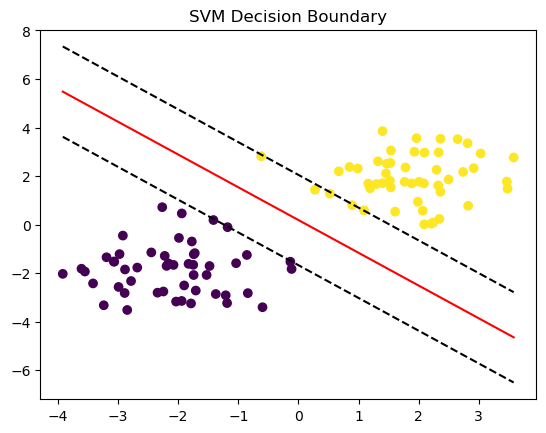

In [4]:
w = model.weights

if model.add_bias:
    b = w[0]
    w1 = w[1]
    w2 = w[2]
else:
    b = 0
    w1 = w[0]
    w2 = w[1]

# Create line
x_vals = np.linspace(X_train[:,0].min(), X_train[:,0].max(), 100)
y_vals = -(b + w1 * x_vals) / w2

# Plot points
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
margin1 = -(b + w1 * x_vals - 1) / w2
margin2 = -(b + w1 * x_vals + 1) / w2

plt.plot(x_vals, margin1, 'k--')
plt.plot(x_vals, margin2, 'k--')

# Plot decision boundary
plt.plot(x_vals, y_vals, 'r')

plt.title("SVM Decision Boundary")
plt.show()

### 6. Visualization

- Scatter plot shows the two classes  
- Red line represents the **decision boundary**  
- Dashed lines represent the **margins**  

---